In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [2]:
df = pd.read_csv("../literacy_data.csv")
df.head()

,indicatorId,geoUnit,year,value,qualifier,magnitude
0,LR.AG15T99,ABW,2000,97.290001,NaN,NaN
1,LR.AG15T99,ABW,2010,96.820000,NaN,NaN
2,LR.AG15T99,AFG,1979,18.160000,NaN,NaN
3,LR.AG15T99,AFG,2011,31.450001,NaN,NaN
4,LR.AG15T99,AFG,2015,33.750000,UIS_EST,NaN


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 9818
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 9818 entries, 0 to 9817
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   indicatorId  9818 non-null   str    
 1   geoUnit      9818 non-null   str    
 2   year         9818 non-null   int64  
 3   value        9818 non-null   float64
 4   qualifier    1314 non-null   str    
 5   magnitude    0 non-null      float64
dtypes: float64(2), int64(1), str(3)
memory usage: 865.2 KB


In [4]:
df.isnull().sum()

indicatorId       0
geoUnit           0
year              0
value             0
qualifier      8504
magnitude      9818
dtype: int64

In [5]:
df = df[['geoUnit','year','value']]

df.columns = [
    'Country',
    'Year',
    'LiteracyRate'
]

df.head()

,Country,Year,LiteracyRate
0,ABW,2000,97.290001
1,ABW,2010,96.820000
2,AFG,1979,18.160000
3,AFG,2011,31.450001
4,AFG,2015,33.750000


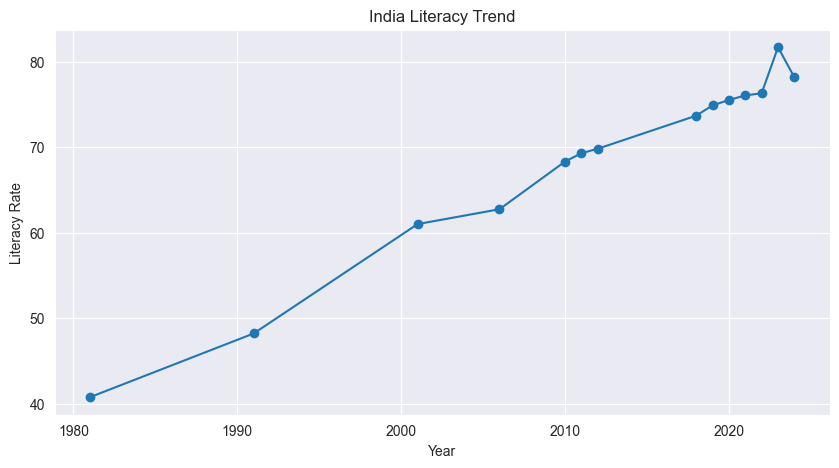

In [6]:
india = df[df['Country'] == 'IND']

plt.figure(figsize=(10,5))

plt.plot(
    india['Year'],
    india['LiteracyRate'],
    marker='o'
)

plt.title("India Literacy Trend")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")

plt.show()

In [7]:
latest_year = df['Year'].max()

latest_df = df[
    df['Year'] == latest_year
]

latest_df.sort_values(
    by='LiteracyRate',
    ascending=False
).head(10)

,Country,Year,LiteracyRate
1918,ECE: CIS (CWG) (UNSDCode:98201),2024,99.910004
1960,"ECE: Eastern Europe, Caucasus and Central Asia...",2024,99.910004
2002,ECE: Eurasian Economic Union (EAEU) (UNSDCode:...,2024,99.900002
2688,ESCAP: North and Central Asia (NCA) (UNSDCode:...,2024,99.900002
98,AIMS: Central Asia,2024,99.879997
5526,SDG: Central Asia,2024,99.879997
3645,"GPE: Europe & Central Asia WB FY24, December 2024",2024,99.860001
4606,MDG: Caucasus and Central Asia,2024,99.860001
6518,UIS: Central Asia,2024,99.839996
3543,GEO,2024,99.680000


In [8]:
growth = []

for c in df['Country'].unique():

    temp = df[df['Country']==c]

    if len(temp)>1:

        g = (
            temp['LiteracyRate'].max()
            -
            temp['LiteracyRate'].min()
        )

        growth.append([c,g])

growth_df = pd.DataFrame(
    growth,
    columns=['Country','Growth']
)

growth_df.sort_values(
    by='Growth',
    ascending=False
).head(10)

,Country,Growth
151,IRN,52.396816
21,BGD,49.770000
18,BDI,48.827479
206,NPL,48.139999
14,ARE,45.299999
125,GNB,43.970001
85,EGY,43.880385
182,MDG: Southern Asia (excluding India),42.349998
115,ESCWA: Maghreb subregion (UNSDCode:98504),41.919998
222,RWA,41.810001


In [9]:
print("""
Project Conclusion

1. Literacy rates have improved globally.
2. Several countries show strong growth.
3. Historical trends can be used for forecasting.
4. Data analytics helps education planning.
""")


Project Conclusion

1. Literacy rates have improved globally.
2. Several countries show strong growth.
3. Historical trends can be used for forecasting.
4. Data analytics helps education planning.

